### 1. Dạng của Linear Regression 
- Ví dụ về dạng tuyến tính:
$$ y \approx f(x) = \hat y$$
$$f(x) = w_1x_1 + w_2x_2 + w_3x_3 + w_0 $$
- Giải thích trong đó: 
    - $w_0, ..., w3$ là các hằng số, $w_0$ còn được gọi là bias
    - $\hat y$ là giá trị đoán, y là giá trị outcome trong tập training
    - Bài toán trên là đi xác đinh các hằng số tối ưu $w_0, ..., w_3$ sao cho giá trí $y - \hat y$ là nhỏ nhất

- Trong phương trình trên, nếu chúng ta đặt **w** =  $[w_0, w_1, w_2, w_3]^{T}$ là các vector cột các hệ số cần phải tối ưu. Đặt $\bar x = [1, x_1, x_2, x_3]$ là vector hàng dữ liệu đầu vào.        KHi đó:
$$ y \approx \bar{x} \mathbf{w} = \hat{y}$$



### 2. Sai số dự đoán
- Đặt e là sai khác giữa y và $\hat y$ khi đó:
$$ \frac{1}{2} e^{2} = \frac{1}{2}(y - \hat y) = \frac{1}{2}(y - \bar{x}\mathbf{w})


### 3. Hàm mất mát
- Điều tương tự sẽ xảy ra  với tất cả các cặp (input, outcome) ($x_i, y_i$) nên ta có được hàm mất mát:
$$L(\mathbf{w}) = \frac{1}{2} \sum_{i = 0}^{N}(y_i - \bar{x_i}w)^{2}$$

- Chúng ta luôn muốn sự mất mát là nhỏ nhất nên chúng ta sẽ đi tìm các hệ số tối ưu sao cho hàm mất mát đạt được giá trị nhỏ nhất:
$$\mathbf{w}^{*} = \arg\min_{\mathbf{w}} L(\mathbf{w})$$

- Đặt $\bar{\mathbf{X}} = [\mathbf{\bar{x}_1}, \mathbf{\bar{x}_2}, ..., \mathbf{\bar{x}_N}]$ là ma trận dữ liệu đầu vào mà mỗi hàng của nó là một điểm dữ liệu. Đặt $\mathbf{y} = [y_1; y_2; ...; y_N] là một vector cột chứa tất cả các ouput của trainning set khi đó:
$$L(\mathbf{w}) = \frac{1}{2} \sum_{i = 0}^{N}(y_i - \bar{x_i}w)^{2}$$
$$= \frac{1}{2}||\mathbf{y} - \mathbf{\bar{X}} \mathbf{w}||^{2}_2$$


### 4. Nghiệm cho bài toán Linear Regression
- Đạo hàm theo $\bar{w} $ của $ L(\mathbf{w})$ ta có:
$$\frac{\partial L(\mathbf{w})}{\partial\mathbf{w}} = \mathbf{\bar{X}^{T}}(\mathbf{\bar{X}}\mathbf{w} - \bar{y})$$
$$ \mathbf{\bar{X}}^{T} \mathbf{\bar{X}} \mathbf{w} = \mathbf{\bar{X}}^{T} \mathbf{y}$$

- Đặt A = $\mathbf{\bar{X}}^{T} \mathbf{\bar{X}}$ và b = $\mathbf{\bar{X}}^{T} \mathbf{y}$ khi đó:
$$A \mathbf{w} = b$$

-Nếu ma trận vuông A =  $\mathbf{\bar{X}}^{T} \mathbf{\bar{X}}$ khả nghịch thì phương trình có nghiệm duy nhất:
$$ \mathbf{\bar{w}} = A^{-1}b$$
$$ \mathbf{\bar{w}} = (\mathbf{\bar{X}}^{T} \mathbf{\bar{X})^{-1}}\mathbf{\bar{X}}^{T} \mathbf{y}$$


### 5. Nên dùng linear regression khi nào. Và hạn chế của nó
- hàm số $y \approx f(x) = \mathbf(w)^T \mathbf{x}$ là một hàm tuyến tính theo cả $\mathbf{w}$ và $\mathbf{x}$. Trên thực thế, Linear Regression có thể áp dụng cho các mô hình chỉ cần tuyến tính theo $\mathbf{w}$
- Hạn chế của Linear Regression: 
    - Nó rất nhạy cảm và hạn chế với điểm nhiễu
    - không biểu diễn được các mô hình phức tạp 

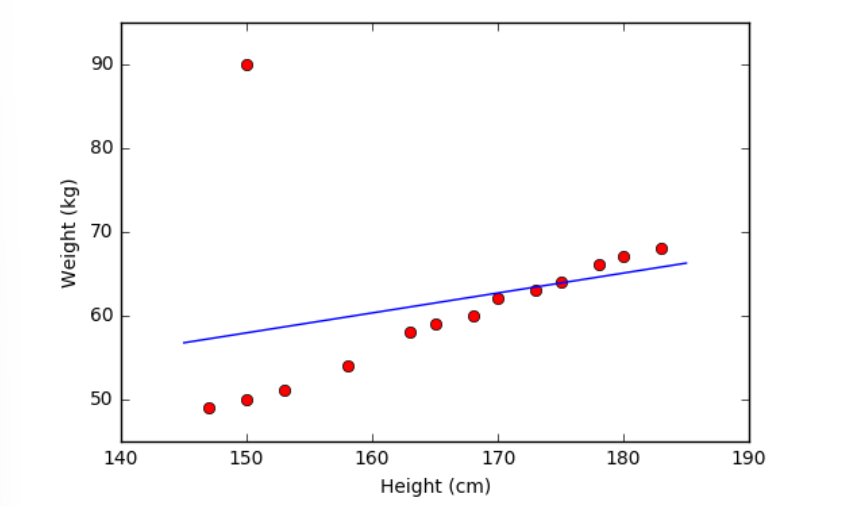

### 6. Ví dụ 
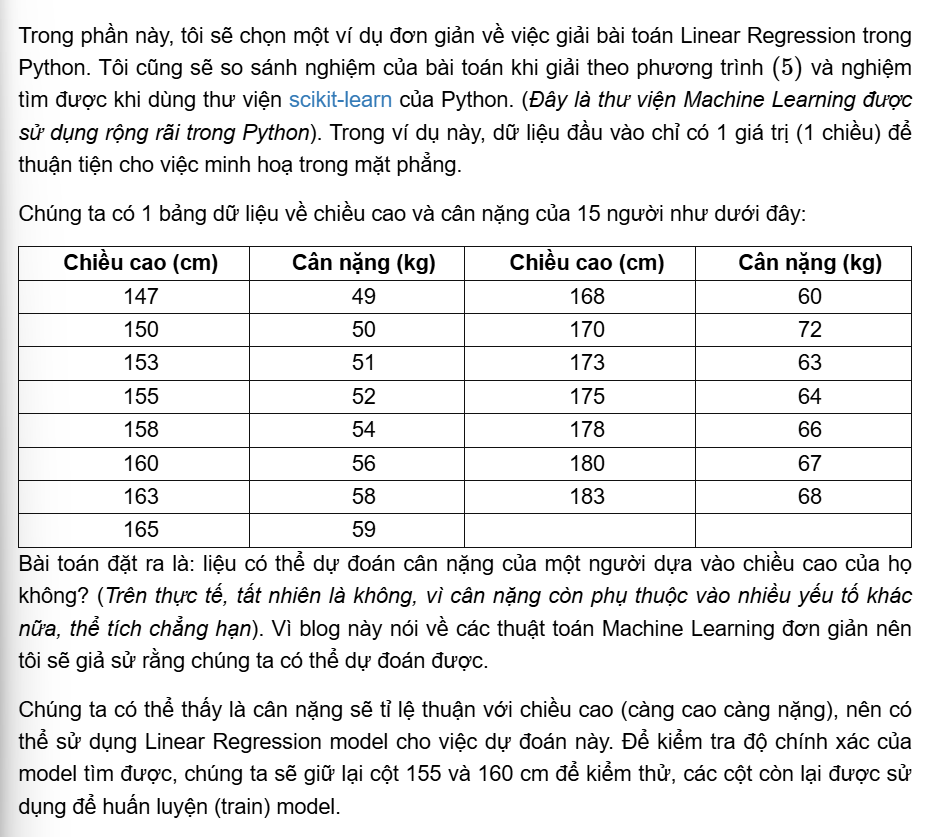

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Height
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T
# weight (kg)
y = np.array([[ 49, 50, 51,  54, 58, 59, 60, 62, 63, 64, 66, 67, 68]]).T


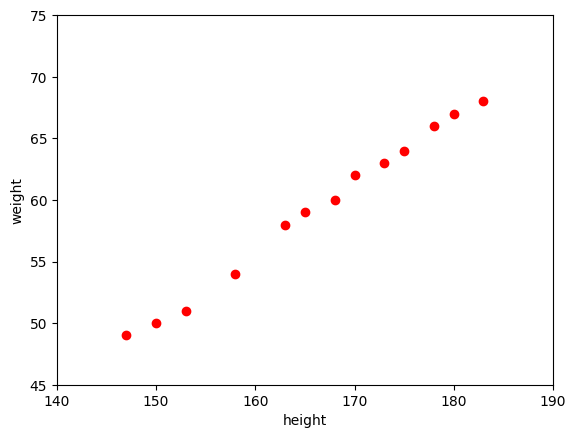

In [8]:
plt.xlabel('height')
plt.ylabel('weight')
plt.plot(X, y, 'or')
plt.axis([140, 190, 45, 75])
plt.show()

[[-33.73541021]
 [  0.55920496]]


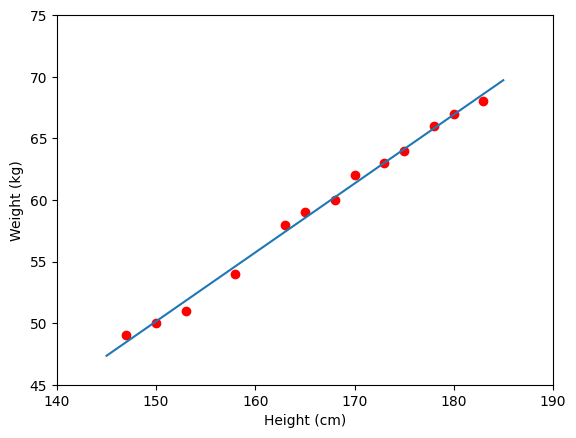

In [17]:
one = np.ones((len(X), 1))
Xbar = np.concatenate((one, X), axis= 1)

A = np.dot(Xbar.T, Xbar)
B = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), B)
print(w)
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1*x0


plt.plot(X.T, y.T, 'ro')     
plt.plot(x0, y0)               
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()




In [18]:
y1 = w_1*155 + w_0
y2 = w_1*160 + w_0

print( u'Predict weight of person with height 155 cm: %.2f (kg), real number: 52 (kg)'  %(y1) )
print( u'Predict weight of person with height 160 cm: %.2f (kg), real number: 56 (kg)'  %(y2) )

Predict weight of person with height 155 cm: 52.94 (kg), real number: 52 (kg)
Predict weight of person with height 160 cm: 55.74 (kg), real number: 56 (kg)
